### 통신사 고객 이탈

In [6]:
import pandas as pd

df = pd.read_excel('./data/Telco_customer_churn.xlsx')

print(df.head())

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [ ]:
print(len(df.columns))
print(df.columns.tolist())
print(df.dtypes)

# 고객 ID
# 고객 수
# 국가
# 주
# 도시 
# 우편번호
# 위도 경도
# 성별
# 노인
# 배우자

# 부양가족
# 계약 기간
# 전화 서비스
# 다중 회선
# 인터넷 서비스
# 온라인 보안
# 온라인 백업
# 기기보호
# 기술 지원
# 스트리밍 TV

# 스트리밍 영화
# 계약
# 무서류 청구
# 결제 방법
# 월 요금
# 총 요금
# 이탈 라벨
# 이탈 가치
# 이탈 점수
# CLTV

# 이탈 사유

In [ ]:
print(df.isnull().sum())

In [ ]:
print(df.describe())

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

# churn Reason 결측치 5174? 결측 사유

In [ ]:
df = df.drop(columns=['Churn Reason'])

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

print(df['Total Charges'].isnull().sum())

# 총 청구 금액 공백을 결측치로 변경 후 제거 예정

In [ ]:
df = df.dropna()

print(df.shape)

# 결측치가 있는 행은 고작 11개, 삭제해도 타격없음. 데이터 7032개;;

In [ ]:
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City',
    'Zip Code', 'Lat Long', 'Latitude', 'Longitude'
]

df = df.drop(columns=drop_cols)

# 불 필요하다 판단되는 컬럼 드랍

In [ ]:
print(df.shape)

In [ ]:
# 이상치 처리
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower) & (df[column] <= upper)]

df = remove_outliers(df, 'Monthly Charges')
df = remove_outliers(df, 'Total Charges')
df = remove_outliers(df, 'Tenure Months')

print(df.shape)

In [ ]:
print(df['Churn Value'].value_counts())

# 유지 5163
# 이탈 1869

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

df = pd.get_dummies(df, drop_first=True)

print(df.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
print(df.columns)

### telcom_churn_ML_dataset.csv

In [7]:
import pandas as pd

df = pd.read_excel('./data/Telco_customer_churn.xlsx')

print(df.shape)
print(df.head())

(7043, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly C

In [8]:
print(df.dtypes)

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object


In [9]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

print(df['Total Charges'].dtype)
print(df['Total Charges'].isnull().sum()) # 결측치가 된 값 11개

float64
11


In [10]:
df = df.dropna(subset=['Total Charges'])

print(df.shape)

# 7043행에서
# Total Charges 문제 있는 11행만 제거
# 최종 7032행 유지

(7032, 33)


In [11]:
y = df['Churn Value']

print(y.shape)
print(y.value_counts())

(7032,)
Churn Value
0    5163
1    1869
Name: count, dtype: int64


In [12]:
drop_cols = [
    'CustomerID', # 고객 ID
    'Count', # 고객 수
    'Country', # 국가
    'State', # 주
    'City', # 시
    'Gender', # 성별
    'Zip Code', # 우편번호
    'Lat Long', # 위도 경도
    'Latitude', # 위도
    'Longitude', # 경도
    'Churn Reason', # 이탈 사유
    'Churn Label', # 이탈 라벨
    'Churn Value', # 이탈 금액
    'Churn Score' # 이탈 점수
]

X = df.drop(columns=drop_cols)

print(X.shape)
print(X.columns.tolist())

# Senior Citizen 노인시민 
# Partner 파트너
# Dependents 부양 가족
# Tenure Months 계약 기간 ★
# Phone Service 전화 서비스
# Multiple Lines 다중 회선
# Internet Service 인터넷 서비스 ★
# Online Security 온라인 보안
# Online Backup 온라인 백업
# Device Protection 기기보호 
# Tech Support 기술 지원
# Streaming TV 스트리밍 TV
# Streaming Movies 스트리밍 영화
# Contract 계약 ★
# Paperless Billing 청구서 
# Payment Method 결제 방법 ★
# Monthly Charges 월요금 ★
# Total Charges 총요금 
# CLTV CLTC

(7032, 19)
['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']


In [13]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(7032, 30)


In [14]:
print(X.columns.tolist())

['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV'] # 숫자형 컬럼들
X[num_cols] = scaler.fit_transform(X[num_cols])

print(X[num_cols].head())

# 수치형 데이터 스케일링
# 평균 = 0 , 표준 편차 = 1

   Tenure Months  Monthly Charges  Total Charges      CLTV
0      -1.239504        -0.363923      -0.959649 -0.983181
1      -1.239504         0.196178      -0.940457 -1.438215
2      -0.995040         1.158489      -0.645369  0.820883
3      -0.180161         1.329677       0.336516  0.508788
4       0.675462         1.293113       1.214589  0.793818


In [16]:
final_df = pd.concat([X, y], axis=1)

print(final_df.shape)
print(final_df.head())

(7032, 31)
   Tenure Months  Monthly Charges  Total Charges      CLTV  \
0      -1.239504        -0.363923      -0.959649 -0.983181   
1      -1.239504         0.196178      -0.940457 -1.438215   
2      -0.995040         1.158489      -0.645369  0.820883   
3      -0.180161         1.329677       0.336516  0.508788   
4       0.675462         1.293113       1.214589  0.793818   

   Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0               False        False           False               True   
1               False        False            True               True   
2               False        False            True               True   
3               False         True            True               True   
4               False        False            True               True   

   Multiple Lines_No phone service  Multiple Lines_Yes  ...  Streaming TV_Yes  \
0                            False               False  ...             False   
1              

In [17]:
final_df.to_csv('telco_churn_ml_ready.csv', index=False)

print("저장 완료")

저장 완료


### churn_customers_only.csv

In [ ]:
import pandas as pd

df = pd.read_excel('./data/Telco_customer_churn.xlsx')

print(df.shape)
print(df.head())

(7043, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly C

In [22]:
# 이탈 고객만 추출
churn_df = df[df['Churn Value'] == 1]

print(churn_df.shape)

(1869, 33)


In [23]:
print(churn_df['Churn Value'].value_counts())

Churn Value
1    1869
Name: count, dtype: int64


In [24]:
churn_df.to_csv('churn_only.csv', index=False)

print("이탈자 데이터 저장 완료")

이탈자 데이터 저장 완료


In [ ]:
# 이탈자 최종 종합 코드
import pandas as pd

# 원본 데이터 불러오기
df = pd.read_excel('./data/Telco_customer_churn.xlsx')

# print(df.shape)
# print(df.head())

churn_df = df[df['Churn Value'] == 1]

churn_df.to_csv('churn_only.csv', index=False)

print("이탈자 데이터 저장 완료")

### 상관관계 분석

In [26]:
import pandas as pd

df = pd.read_excel('./data/Telco_customer_churn.xlsx')

print(df.shape)
print(df.head())

(7043, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly C

In [27]:
# Total Charges를 숫자형으로 변환
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# 변환 후 결측치 개수 확인
print(df['Total Charges'].isnull().sum())

11


In [28]:
df = df.dropna(subset=['Total Charges'])

print(df.shape)

(7032, 33)


In [29]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

print(numeric_df.columns)
print(numeric_df.shape)

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='str')
(7032, 10)


In [30]:
corr = numeric_df.corr()

print(corr)

                 Count  Zip Code  Latitude  Longitude  Tenure Months  \
Count              NaN       NaN       NaN        NaN            NaN   
Zip Code           NaN  1.000000  0.895795  -0.784273       0.000287   
Latitude           NaN  0.895795  1.000000  -0.876777      -0.002100   
Longitude          NaN -0.784273 -0.876777   1.000000      -0.001477   
Tenure Months      NaN  0.000287 -0.002100  -0.001477       1.000000   
Monthly Charges    NaN -0.004956 -0.020302   0.024513       0.246862   
Total Charges      NaN -0.001462 -0.010313   0.009047       0.825880   
Churn Value        NaN  0.003006 -0.003600   0.004693      -0.354049   
Churn Score        NaN -0.002538 -0.007471   0.003724      -0.226379   
CLTV               NaN -0.004512  0.000137   0.000953       0.396188   

                 Monthly Charges  Total Charges  Churn Value  Churn Score  \
Count                        NaN            NaN          NaN          NaN   
Zip Code               -0.004956      -0.001462     0

In [31]:
churn_corr = corr['Churn Value'].sort_values(ascending=False)

print(churn_corr)

Churn Value        1.000000
Churn Score        0.664970
Monthly Charges    0.192858
Longitude          0.004693
Zip Code           0.003006
Latitude          -0.003600
CLTV              -0.128253
Total Charges     -0.199484
Tenure Months     -0.354049
Count                   NaN
Name: Churn Value, dtype: float64


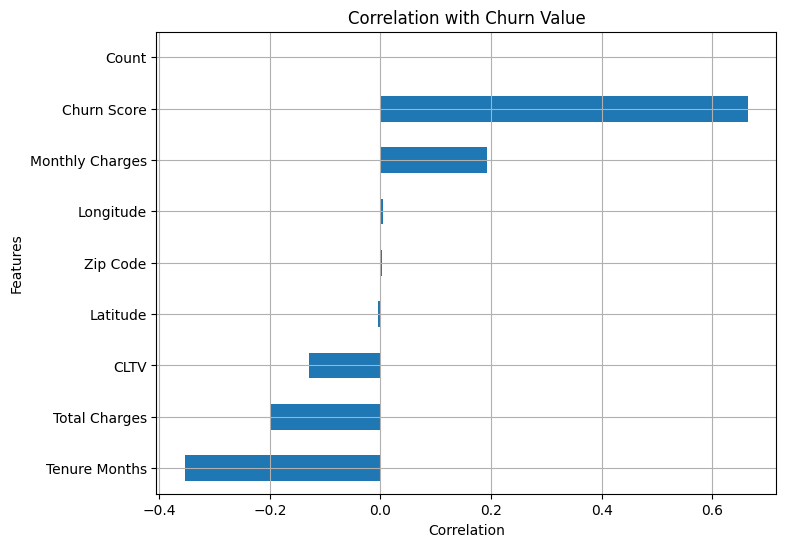

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
churn_corr.drop('Churn Value').sort_values().plot(kind='barh')
plt.title('Correlation with Churn Value')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.grid(True)
plt.show()

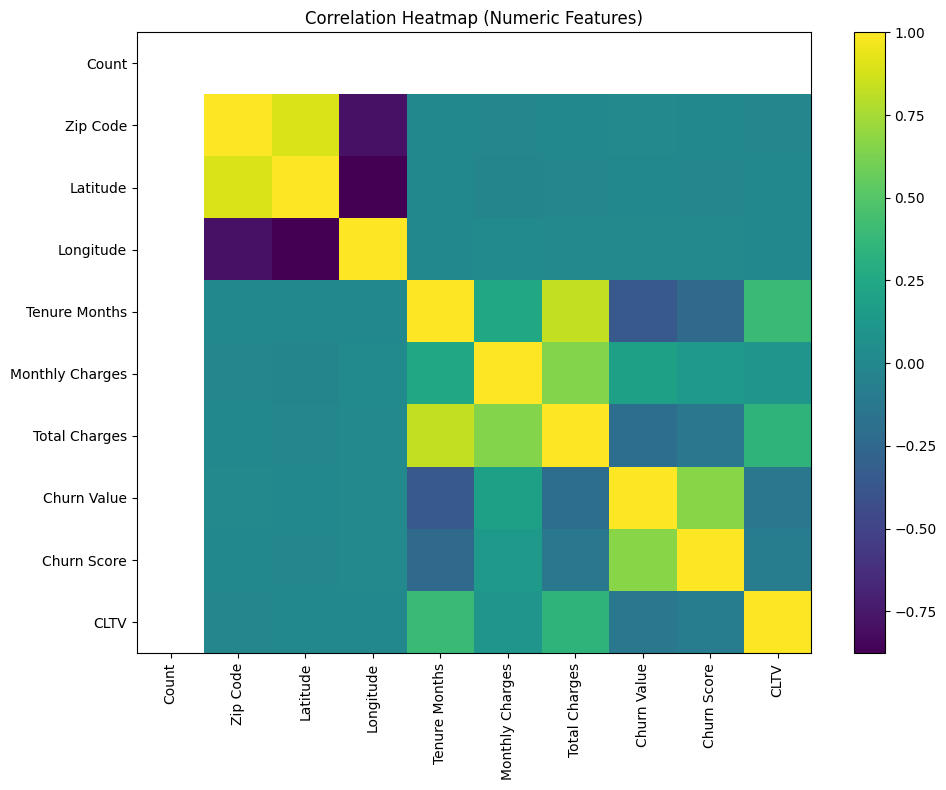

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


# 가입 기간이 짧을수록 이탈 up
# 월 요금이 높을수록 이탈 up
# 총 요금이 높을수록 이탈 up
# 무약정이면 이탈 up



### 이탈자 전용 분석/군집화 데이터셋

* 데이터 
* 결측치 처리
* 이상치 처리
* 이탈자만 추출
* 인코딩
* 상관관계 분석
* 이탈자와 관련 깊은 컬럼 선택
* CSV 저장


In [54]:
import pandas as pd

df = pd.read_excel('data/Telco_customer_churn.xlsx')

# 문자열로 되어있는 총요금(Total Charges) 숫자형으로 변환
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Total Charges 결측치 제거
df = df.dropna(subset=['Total Charges'])

# 계약 기간, 월 요금, 총 요금, 고객 생애 가치
numeric_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

# 이상치 제거
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    filtered_df = dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]
    return filtered_df

for col in numeric_cols:
    before = df.shape[0]
    df = remove_outliers_iqr(df, col)
    after = df.shape[0]
    print(f"{col}: {before} -> {after}")

# 이탈자 추출
churn_df = df[df['Churn Value'] == 1].copy()

# drop_cols = [
#     'CustomerID',# 식별자
#     'Count',# 상수값
#     'Country', # 국가
#     'State', # 주
#     'City', # 시
#     'Zip Code', # 우편번호
#     'Lat Long', # 위도경도
#     'Latitude', # 위도
#     'Longitude', # 경도
#     'Churn Label',# Churn Value와 중복
#     'Churn Reason',# 결과 이후 정보, 분석용으로는 따로 보관 가능
#     'Churn Score'# 누수 가능성 큼
# ]

selected_cols = [
    'Tenure Months',
    'Monthly Charges',
    'Contract_Month-to-month',
    'Internet Service_Fiber optic',
    'Payment Method_Electronic check'
]


Tenure Months: 7032 -> 7032
Monthly Charges: 7032 -> 7032
Total Charges: 7032 -> 7032
CLTV: 7032 -> 7032


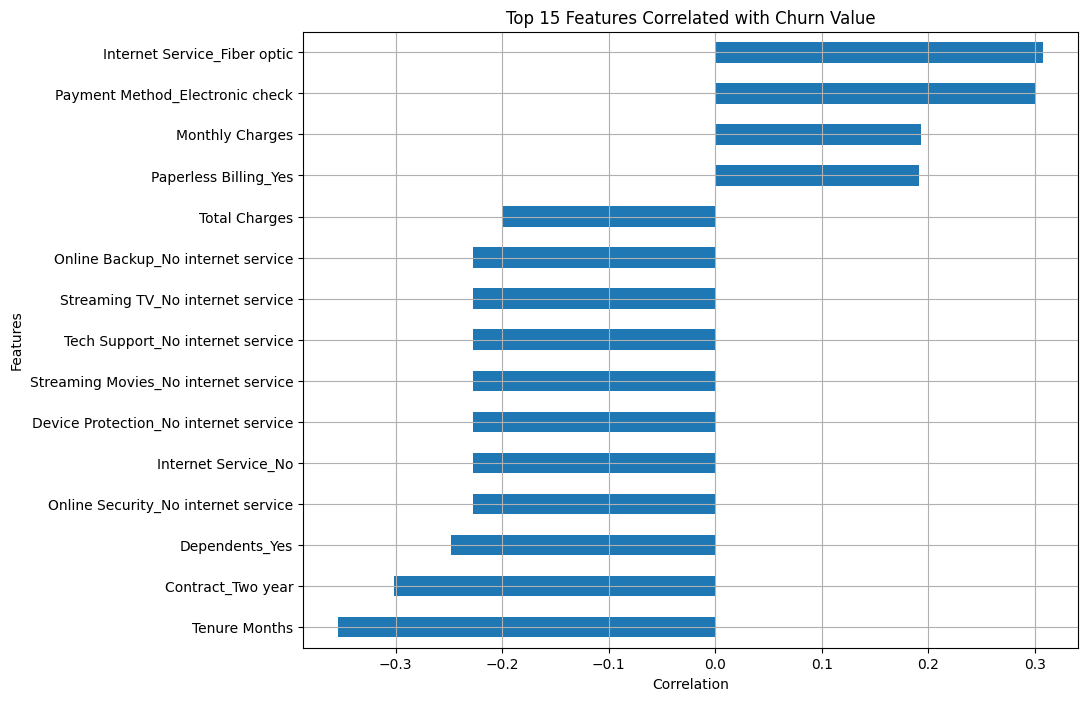

In [55]:
import matplotlib.pyplot as plt

# 전체 데이터 다시 불러오기
full_df = pd.read_excel('data/Telco_customer_churn.xlsx')

# Total Charges 처리
full_df['Total Charges'] = pd.to_numeric(full_df['Total Charges'], errors='coerce')
full_df = full_df.dropna(subset=['Total Charges'])

# 이상치 처리
for col in numeric_cols:
    full_df = remove_outliers_iqr(full_df, col)

# 불필요 컬럼 제거
full_df = full_df.drop(columns=drop_cols)

# 인코딩
full_encoded = pd.get_dummies(full_df, drop_first=True)

corr = full_encoded.corr()

churn_corr = corr['Churn Value'].drop('Churn Value').sort_values(key=abs, ascending=False)

top_corr = churn_corr.head(15)

plt.figure(figsize=(10, 8))
top_corr.sort_values().plot(kind='barh')
plt.title('Top 15 Features Correlated with Churn Value')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.grid(True)
plt.show()



In [ ]:
# 이탈자만 있음
# 결측치 처리 완료
# 이상치 처리 완료
# 인코딩 완료
# 상관관계 기반 중요 컬럼만 선택 완료

final_churn_ml_df.to_csv('churn_only_2.csv', index=False)

print("최종 이탈자 전용 ML 데이터 저장 완료")

최종 이탈자 전용 ML 데이터 저장 완료


In [49]:
check_df = pd.read_csv('churn_only_2.csv')

print(check_df.shape)
print(check_df.head())
print(check_df.isnull().sum().sum())

(1869, 15)
   Tenure Months  Internet Service_Fiber optic  Contract_Two year  \
0              2                         False              False   
1              2                          True              False   
2              8                          True              False   
3             28                          True              False   
4             49                          True              False   

   Payment Method_Electronic check  Dependents_Yes  \
0                            False           False   
1                             True            True   
2                             True            True   
3                             True            True   
4                            False            True   

   Online Security_No internet service  Internet Service_No  \
0                                False                False   
1                                False                False   
2                                False                False 

## **상관관계 분석**

1. 데이터 불러오기
2. 타입 확인
3. TotalCharges 처리
4. 인코딩
5. 상관관계 계산
6. Churn 기준 분석
7. 그래프 시각화

In [57]:
import pandas as pd

df = pd.read_csv('Telco-Customer-Churn.csv')

print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [58]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [59]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].isnull().sum())

11


In [60]:
df = df.dropna(subset=['TotalCharges'])

print(df.shape)

(7032, 21)


In [61]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [62]:
df = df.drop(columns=['customerID'])

print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [63]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)

(7032, 31)


In [71]:
corr = df_encoded.corr()

churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

print(churn_corr.head(10))

tenure                                 -0.354049
InternetService_Fiber optic             0.307463
Contract_Two year                      -0.301552
PaymentMethod_Electronic check          0.301455
InternetService_No                     -0.227578
OnlineSecurity_No internet service     -0.227578
DeviceProtection_No internet service   -0.227578
TechSupport_No internet service        -0.227578
StreamingMovies_No internet service    -0.227578
StreamingTV_No internet service        -0.227578
Name: Churn, dtype: float64


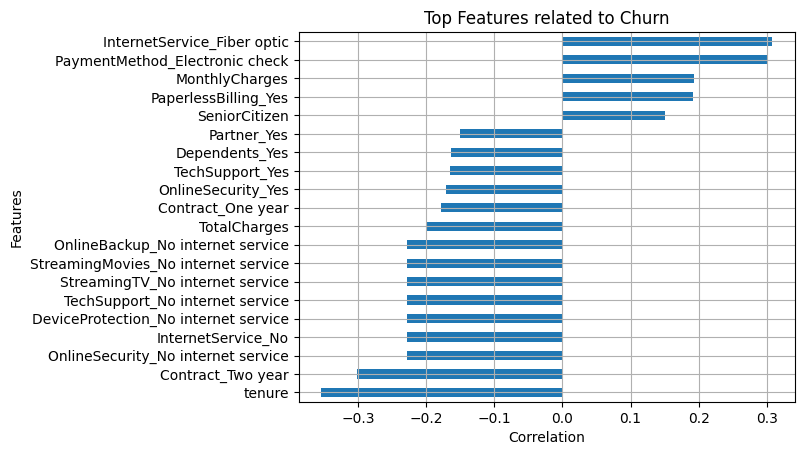

In [ ]:
import matplotlib.pyplot as plt

top_corr = churn_corr.head(20)

plt.figure()
top_corr.sort_values().plot(kind='barh')
plt.title('Top Features related to Churn')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.grid(True)
plt.show()

# 이탈과 관련 깊은 컬럼
# 광케이블 인터넷 쓰는 고객 이탈 
# 전자수표 결제 이탈 
# 월 요금 높을수록 이탈
# 전자 청구서 이탈
# 노년층 이탈


# 가입기간
# 안정 계약

### 최종 CSV 파일

In [ ]:
import pandas as pd

df = pd.read_csv('Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

df = df.drop(columns=['customerID'])

print(df.shape)

(7032, 20)


In [77]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]

for col in numeric_cols:
    df = remove_outliers_iqr(df, col)

print(df.shape)

(7032, 20)


In [78]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)

(7032, 31)


In [ ]:
selected_cols = [
    'tenure', # 가입 기간
    'MonthlyCharges', # 월 요금
    'InternetService_Fiber optic', # 고가 서비스(광케이블 인터넷)
    'PaymentMethod_Electronic check', # 위험 결제
    'Contract_Two year', # 약정
    'OnlineSecurity_Yes' # 보안 서비스
]

X = df_encoded[selected_cols]
y = df_encoded['Churn']

print(X.shape)
print(y.shape)

(7032, 6)
(7032,)


In [80]:
final_df = pd.concat([X, y], axis=1)

final_df.to_csv('telco_churn_final_ml.csv', index=False)

print("최종 ML 데이터 저장 완료")

최종 ML 데이터 저장 완료
